<center>

## <font color='blue'>ASTR 21100</font>
<center>

### <font color='blue'>"Computational Techniques in Astrophysics"</font>
    
<center>
    
### <font color='blue'> Integrating particle trajectory in a gravitational field</font>

<center>
    
### <font color='blue'> 10 points (+ 6 possible extra-credit points)</font>
    
    
<center>

### <font color='blue'> Due Wednesday,  Jan 10, 10pm</font>



<p>
<center>
<a href="https://www.esa.int/Science_Exploration/Space_Science/Gaia/Galactic_crash_may_have_triggered_Solar_System_formation"><img width=600 src="https://www.esa.int/var/esa/storage/images/esa_multimedia/images/2020/05/sagittarius_collisions_trigger_star_formation_in_milky_way/22031413-3-eng-GB/Sagittarius_collisions_trigger_star_formation_in_Milky_Way_pillars.jpg"></img></a>
</center>

In this assignment you will use the simple KD method for computing trajectory of a particle in a gravitational field to 

1. identify key difference in orbits in extended mass distributions and around point-mass (exercise 1) 
<br>
2. Calculate trajectory of the Sagittarius dwarf galaxy orbiting around the Milky Way over the past 4 billion years (exercise 2 OR 3). 
<br>

Key imports

In [1]:
import numpy as np

# use jupyter "magic" command to tell it to embed plot into the notebook 
import matplotlib.pyplot as plt
%matplotlib inline

# see message in Slack channel #general for how to make this import to work
from codes.plotting import plot_prettier
plot_prettier()

Values of various quantities and constants used in the code below. 

In [2]:
AU = 1.49598e+13 # 1 AU = average distance from the Earth to the Sun in centimeters (cm)
G = 6.67259e-08 # universal gravitational constant in cgs units 
msun = 1.9891e33 # mass of the Sun in grams
yr =  365.25 * 24 * 60 * 60 # 1 year in seconds
kpc = 3.08568e+21 # kiloparsec in cm


In [3]:
def time_stepping(x0, v0, t0, tend, dt, *args, acc_func=None):
    """
    Implements time stepping for a particle's motion in three dimensions.

    This function updates the position and velocity of a particle over a series of time steps from t0 to tend.
    The acceleration of the particle at each time step is obtained by calling the acc_func function.

    Parameters:
    x0 (array-like): Initial coordinates of the particle at time t0, format [x, y, z].
    v0 (array-like): Initial velocity components of the particle at time t0, format [vx, vy, vz].
    t0 (float): Initial time.
    tend (float): End time.
    dt (float): Time step for the update.
    args: tuple of parameters to be passed to the acc_func 
    acc_func (function): A function that takes the current position (x) and velocity (v)
                         and returns the acceleration components as an array [ax, ay, az].

    Returns:
    array: arrays of time [shape =(nsteps)], positions [shape=(nsteps,3)], velocities [shape=(nsteps,3)].
    """

    # initialize time and arrays to keep coordinate and velocity components
    t = t0
    x, v = np.array(x0), np.array(v0)

    # Initialize lists to store times, coordimates, and velocities along trajectory
    time, xt, vt = [np.copy(t)], [np.copy(x0)], [np.copy(v0)]

    # Time stepping loop
    while t < tend:
        # Calculate acceleration components using the provided function
        a = np.array(acc_func(x, *args))

        # Update velocity and position using the KD scheme
        v += a * dt
        x += v * dt

        # Update time
        t += dt

        # Append current state to the trajectory
        time.append(t)
        xt.append(np.copy(x))
        vt.append(np.copy(v))
        
    return np.array(time), np.array(xt), np.array(vt)

In [4]:
def plot_traj_xy_xz(xt, xlab1='$x$', ylab1='$y$', xlab2='$x$', ylab2='$z$', lw=0.5, 
                    xlims=[-1.1, 1.1], ylims=[-1.1, 1.1], xlims2=None, ylims2=None, figsize=(7,3)):
    '''
    Helper function to plot trajectory in the x-y and x-z projections using Matplotlib 
    
    Parameters: 
        xt - arrays of coordinates [shape (nsteps,3)] to plot
        lw - controls width of the plotted lines (must be >0)
    Returns: None
    '''
    fig, ax = plt.subplots(1, 2, figsize=figsize) # define sub-panels
    fig.subplots_adjust(wspace=0.4)

    ax[0].plot(xt[:,0], xt[:,1], lw=lw)
    ax[0].set_xlim(xlims) # set x, and y axes limits 
    ax[0].set_ylim(ylims)
    ax[0].set_ylabel(ylab1) # add labels to axes
    ax[0].set_xlabel(xlab1)

    ax[1].plot(xt[:,0], xt[:,2], lw=lw)
    if xlims2 is None: 
        ax[1].set_xlim(xlims) # set x, and y axes limits 
    else:
        ax[1].set_xlim(xlims2)
    if ylims2 is None: 
        ax[1].set_ylim(ylims) # set x, and y axes limits 
    else:
        ax[1].set_ylim(ylims2)

    ax[1].set_xlabel(xlab2)
    ax[1].set_ylabel(ylab2)
    plt.show()

Function computing acceleration components due to a point mass. 

In [5]:
def acc_point_mass(x, *args):
    """
    Computes acceleration from a point mass at the position with coordinates in x
    Parameters:
        x: array of size 3 with the coordinates of the point in cm
        args[0] must be the mass in grams 
    Returns:
        array of size 3 with the acceleration components in cm/s**2
    """
    m = args[0]
    r = np.sqrt(x[0]**2 + x[1]**2 + x[2]**2)
    return -G * m/r**3 * x


This code should be used for comparisons with results in the exercise 1. 

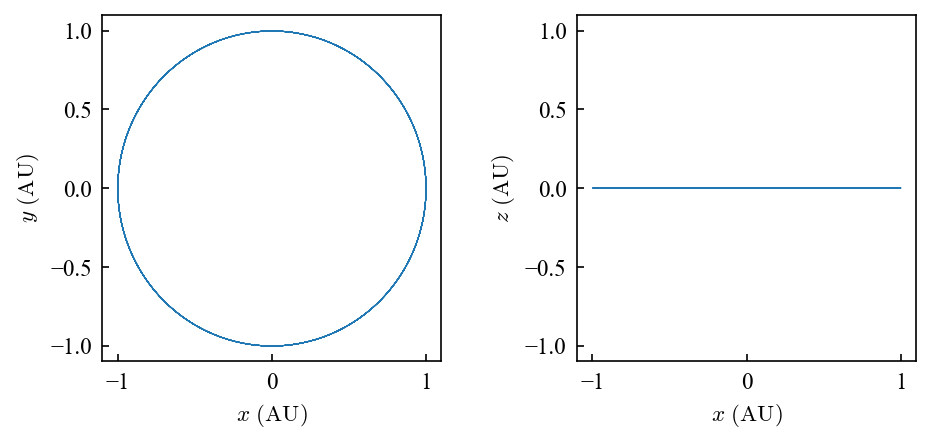

In [6]:
vcirc = (G*msun/AU)**0.5 # circular velocity = sqrt(G*Msun/AU)

# set initial position and velocity
x0 = [AU, 0., 0.] # coordinates of the "Earth"
v0 = [0., vcirc, 0.] # initial velocity of the "Earth" 

t0 = 0.
tend = 10 * yr
dt = (tend - t0) / 10000. 

args = (msun,) # supply mass of the point-mass for acceleration function

t, xt, vt = time_stepping(x0, v0, t0, tend, dt, *args, acc_func=acc_point_mass)

t /= yr # convert time from seconds to years
xt /= AU # convert coordinates from cm to AU 

plot_traj_xy_xz(xt, xlab1=r'$x\rm\ (AU)$', ylab1=r'$y\rm\ (AU)$', 
                     xlab2=r'$x\rm\ (AU)$', ylab2=r'$z\rm\ (AU)$', lw=0.5)

## 1. Calculating trajectory in an extended mass distribution

### 4 points

#### Background info. 
The case of a gravitating point-mass considered in class on Thu, Jan 4 assumes that all of the gravitating mass is in a point, while the rest of space is empty. 
In astrophysics, we often encounter extended mass distribution. For example, stars, gas and dark matter is everywhere in our galaxy, although the overall density of matter is highest near the center of the galaxy and decreases with increasing distance to the center. 

At distances $>10$ kpc from the center matter density distribution can be apporixated quite well by the extended 
 [Navarro-Frenk-White profile](https://en.wikipedia.org/wiki/Navarro%E2%80%93Frenk%E2%80%93White_profile) (NFW). 
The profile assumes that mass distribution is spherically symmetric - that is density depends only on distance to the center $r$. 

Acceleration due to this NFW mass distribution at the location $\vec{r}$ is 
$$\vec{a} =-\frac{GM_{200}}{\ln(1+c) - c/(1+c)}\,\frac{\frac{r}{r+r_s}-\ln\left(1+\frac{r}{r_s}\right)}{r^3}\, \vec{r}
$$

where mass $M_{200}$ is the mass within the radius $R_{200}$, and $r_s$ is the scale radius that defines how concentrated the profile is via the concentration $c=R_{200}/r_s$. These quantities are parameters of the profile that are estimated using observational data. 

#### Tasks
In the code  below the parameters of the NFW mass distribution are similar to the mass distribution around our Milky Way galaxy.  The code sets up initial conditions for a particle on a circular orbit, runs the trajectory calculation, and plots the resulting trajectory in the $x-y$ and $x-z$ projections.

First run the code below as given to make sure that it works and you get a circular trajectory by examining the 2-panel plot of trajectory in the $x-y$ and $x-z$ projections. 
<br>

* **1a (2 points).** Change the $y$-component of the initial velocity from <tt>vcirc</tt> to <tt>0.7vcirc</tt>. Compare resulting trajectory to the trajectory with <tt>0.7vcirc</tt> initial velocity for the point-mass using the code above and identify the most salient difference. Discuss the difference and present a qualitative explanation for why the trajectory is so different in this case. 
<br>

* **1b (2 points).** Change the $y$-component of the initial velocity from to <tt>0.1vcirc</tt>. Compare resulting trajectory to the trajectory with <tt>0.1vcirc</tt> initial velocity for the point-mass using the code above. Discuss the main difference that you can see between this case and the corresponding orbit around the point mass. 

In [7]:
def acc_nfw(x, *args):
    '''Computes acceleration due to the NFW mass distribution at the distance x from the origin
    Parameters:
       x: arrays with 3 coordinates in the system where center of the NFW potential is at the origin
       args: a tuple of size 2 containing total mass M200 in units of Sun's mass and dimensionless concentration c
    Returns:
       numpy array with 3 components of the acceleration
    '''
    m200, c = args[0], args[1]
    r200 = 206.285 * (m200/1e12)**(1./3) # R200 in kpc
    rs = r200 / c * kpc
    r = np.sqrt(x[0]**2 + x[1]**2 + x[2]**2)

    acc = G * m200 * msun / (np.log(1+c) - c/(1+c)) * (r/(r+rs) - np.log(1+r/rs))/r**3 * x
    return acc

In [8]:
def fnfw(x): 
    '''
    Helper function for computing mass within a radius r for the NFW profile
    '''
    assert(x >= 0)
    return np.log(1.+x) - x/(1+x)

def vcirc_nfw(r0=8, m200=9e11, c=10):
    '''
    Compute circular velocity for input distance r0, m200, and concentration c assuming NFW profile
    
    Returns: 
        circular velocity at r0 in cm/s
    '''
    r200 = 206.285 * (m200/1e12)**(1./3) # R200 in kpc
    
    r0 = r0 * kpc
    rs = r200 / c * kpc

    mr0 = m200 * fnfw(r0/rs) / fnfw(c)

    vcirc = (G*mr0*msun / r0)**0.5
    return vcirc

In [9]:
# set initial conditions
r0 = 8 
m200, c = 9e11, 10 # total mass of the Milky Way in Msun and halo concentration
args = (m200, c) 
vcirc = vcirc_nfw(r0=r0, m200=m200, c=c)

x0 = [r0*kpc, 0., 0.] # initial coordinates 
v0 = [0., vcirc, 0.] # initial velocity 

t0 = 0.
tend = 1e9 * yr # duration of calculation
dt = (tend - t0) / 10000. 


t, xt, vt = time_stepping(x0, v0, t0, tend, dt, *args, acc_func=acc_nfw)

t /= (1e6*yr)
xt /= kpc

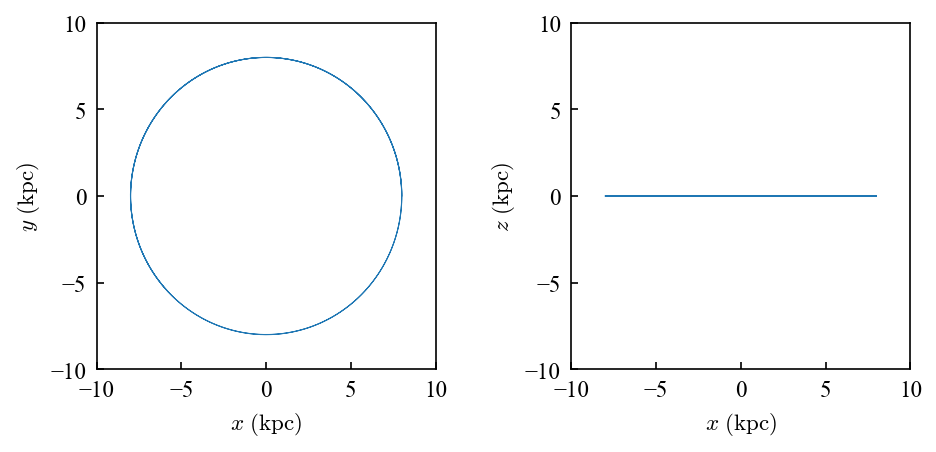

In [10]:
plot_traj_xy_xz(xt, xlab1=r'$x\rm\ (kpc)$', ylab1=r'$y\rm\ (kpc)$', 
                 xlab2=r'$x\rm\ (kpc)$', ylab2=r'$z\rm\ (kpc)$', 
                    xlims=[-10,10], ylims=[-10,10])


## 2. Modeling orbit of Sagittarius dwarf galaxy.

### 6 points 

#### Background info

[Sagittarius dwarf galaxy](https://en.wikipedia.org/wiki/Sagittarius_Dwarf_Spheroidal_Galaxy) was discovered in 1994. Observational measurements showed that it has an orbit that loops around the center of our galaxy and passed near the plane of the Milky Way disk ($z=0$) a few times. In fact, one of these passages may have caused a perturbation in the diffuse gas in the Milky Way disk [and triggered formation of our Sun and solar system](https://www.esa.int/Science_Exploration/Space_Science/Gaia/Galactic_crash_may_have_triggered_Solar_System_formation). 

Modeling by [Thomas et al. 2017](https://www.aanda.org/articles/aa/full_html/2017/07/aa30531-17/aa30531-17.html) showed that a good match to the orbit of the Sagittarius galaxy over the past 4 billion years (astronomers use "gigayear" or Gyr for short to indicate billion years) can be obtained if the initial coordinates and velocity components of the Sagittarius in the coordinate system where Milky Way center is at the origin were 

* $x= -37.05$ kpc, $y=-24.18$ kpc, $z=51.34$ kpc, where kpc is kiloparsec (thousand parsecs) equal to $3.08568\times 10^{21}$ cm.  
<br>

* $v_x = -8.406\times 10^6$ cm/s, $2.760\times 10^6$ cm/s, $-6.441\times 10^6$ cm/s.

#### Task

**2a (3 points).** Using the numbers above set up initial conditions for calculation of the trajectory of the Sagittarius galaxy from time $t=0$ to $t=4$ gigayears using the codes above as an example. Make sure that initial coordinates and velocities supplied to the <tt>time_stepping</tt> function are in cm and cm/s, respectively. 

**2b (2 points).** Run the calculation of the trajectory for 4 gigaryears and plot the resulting trajectory in the $x-y$ and $y-z$ projections. You will need to adjust limits of the plot to something like $[-75, 75]$ kpc using <tt>xlims</tt> and <tt>ylims</tt> arguments to the plotting function. 

**2c (1 point).** Compare the trajectory you obtain in the $x-z$ projection to the trajectory in [Figure 2](https://www.aanda.org/articles/aa/full_html/2017/07/aa30531-17/F2.html) of the Thomas et al. 2017 paper. The trajectory you should obtain should be similar, but will not be exactly the same because the extended NFW mass distribution differs from what was used in that paper. It neglects gravity from the Milky Way, disk for example. 

## 3. Modeling Sagittarius dwarf trajectory in the NFW + disk potential 

### 12 points

#### Background info: 
In the exercises above NFW spherically-symmetric distribution of mass was assumed. This neglects potential of the Milky Way disk. NFW mass distribution approximates mass distribution around the Milky Way galaxy at large distances, but at smaller distances ($r<10$ kpc) contribution of the disk, which is not spherically symmetric, can significantly alter trajectories. In this experiment, you will add the accelerations due to the gravity of stars and gas in the disk of the Milky Way using the  Miyamoto-Nagai model for the mass distribution in the disk that is characterized by the potential: 

$$\phi(R,z) = -\frac{GM_{\rm disk}}{\left[R^2 + (\sqrt{z^2 + b^2} + a)^2\right]^{1/2}},$$

where $R^2 = x^2+y^2$ assuming that the disk mid-plane is in the $x-y$ ($z=0$) plane, $a$ is parameter that characterizes size of the disk and $b$ is the parameter that characterizes thickness of the disk. 

Acceleration components due to mass distribution with this potential are
$$a_x = -\frac{\partial\phi}{\partial x} = -\frac{G M_{\text{disk}}}{\left(x^2 + y^2 + \left(a + \sqrt{b^2 + z^2}\right)^2\right)^{3/2}}\, x$$

$$a_y = -\frac{\partial\phi}{\partial y} = -\frac{G M_{\text{disk}}}{\left(x^2 + y^2 + \left(a + \sqrt{b^2 + z^2}\right)^2\right)^{3/2}}\,y$$

$$a_z = -\frac{\partial\phi}{\partial z} = -\frac{G M_{\text{disk}}}{\left(x^2 + y^2 + \left(a + \sqrt{b^2 + z^2}\right)^2\right)^{3/2}}\,\frac{ \left(a + \sqrt{b^2 + z^2}\right)}{\sqrt{b^2 + z^2} }\,z$$

And the circular velocity for a particle in the midplane of the disk ($z=0$) for this potential is  
$$V_{\rm circ, disk}\vert_{z=0} = \sqrt{R\frac{\partial\phi(R,z)}{\partial R}\vert_{z=0}}= \sqrt{\frac{G M_{\rm disk} R^2}{\left[R^2 + (a+b)^2\right]^{3/2}}}$$

Also read background info for exercise 2 above. 

#### Tasks

* **3a (2 points).** Implement a function calculating accelerations due to disk in cm/s using the expressions above. 
<br>

* **3b (1 point).** Implement a function calculating $v_{\rm circ, disk}$ in cm/s using the expression above. 
<br>

* **3c (1 point).** Implement another function that computes the sum of the accelerations due to the NFW mass distribution with parameters used in exercises 1 and 2 and accelerations due to the disk with parameters similar to that of the Milky Way disk: $M_{\rm disk}=7\times 10^{10}\ M_\odot$ (where $M_\odot=1.9891\times 10^{33}$ grams is the mass of the Sun) with $a=3$ kpc and $b=0.3$ kpc (where kpc is 1000 parsecs or ${\rm kpc}=3.08568\times 10^{21}$ cm as is set in the <tt>kpc</tt> at the beginning of this notebook. 
<br>

* **3d (2 points).** Test your acceleration function by setting particle at the initial coordinates $x=8$ kpc and $y=0$, $z=0$ and initial velocity components: $v_x=0$, $v_y=v_{\rm circ}$, $v_z=0$, where 
$$v_{\rm circ}=\sqrt{v_{\rm circ,NFW}^2(r=8{\,\rm kpc}) + v_{\rm circ, disk}^2(r=8{\,\rm kpc})}$$
where $v_{\rm circ,NFW}$ is the circular velocity calculated by function <tt>vcirc_nfw</tt> above. The correct inegration for a billion years should result in a circular orbit in the $x-y$ plane while $z$ coordinate should remain $0$. 
<br>

* **3e (5 points).** Set up initial conditions for the Sagittarius dwarf as described in exercise 2.  Run the calculation of the trajectory for 4 gigaryears and plot the resulting trajectory in the $x-y$ and $x-z$ projections. You will need to adjust limits of the plot to something like $[-75, 75]$ kpc using <tt>xlims</tt> and <tt>ylims</tt> arguments to the plotting function. 
<br>

* **3f (1 point).** Compare the trajectory you obtain in the $x-z$ projection to the trajectory in [Figure 2](https://www.aanda.org/articles/aa/full_html/2017/07/aa30531-17/F2.html) of the Thomas et al. 2017 paper. The trajectory you should obtain should be similar, but will not be exactly the same because the extended NFW mass distribution differs from what was used in that paper. 